# Fraud Detection

### Table Contents
* [Introduction](#chapter1)
* [Exploratory Data Analysis](#chapter2)
* [Data Preprocessing](#chapter3)
* [Main Problem Of The Dataset](#chapter4)
* [Classic Algorithms Of ML](#chapter5)
* [Isolation Forest](#chapter6)
* [AutoEncoders 1 - Deep NN Architecture](#chapter7)
* [AutoEncoders 2 - Deeper NN Architecture](#chapter8)

## Introduction

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [32]:
df = pd.read_csv('data/Fraud Detection Dataset.csv')
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


# Exploratory Data Analysis 


## 1st Method using traditionnal EDA

In [33]:
print("Shape:", df.shape, '\n')
print("Data Types:", df.dtypes, '\n')
for col in df.columns:
    print(f"Unique Data Of The {col}:", df[col].unique())

Shape: (51000, 12) 

Data Types: Transaction_ID                       object
User_ID                               int64
Transaction_Amount                  float64
Transaction_Type                     object
Time_of_Transaction                 float64
Device_Used                          object
Location                             object
Previous_Fraudulent_Transactions      int64
Account_Age                           int64
Number_of_Transactions_Last_24H       int64
Payment_Method                       object
Fraudulent                            int64
dtype: object 

Unique Data Of The Transaction_ID: ['T1' 'T2' 'T3' ... 'T49998' 'T49999' 'T50000']
Unique Data Of The User_ID: [4174 4507 1860 ... 4616 2261 4210]
Unique Data Of The Transaction_Amount: [1292.76 1554.58 2395.02 ...  647.11 2446.65 2867.43]
Unique Data Of The Transaction_Type: ['ATM Withdrawal' 'Bill Payment' 'POS Payment' 'Bank Transfer'
 'Online Purchase']
Unique Data Of The Time_of_Transaction: [16. 13. nan 15. 19.  2

#### Since our main goal is to fully explore the data and find every important feature, which might help the model to predict the accuracy. Firstly, let's handle missing values, and then try to explore categorical and numerical data

In [34]:
print('Nan Type Values:\n', df.isnull().sum())

Nan Type Values:
 Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64


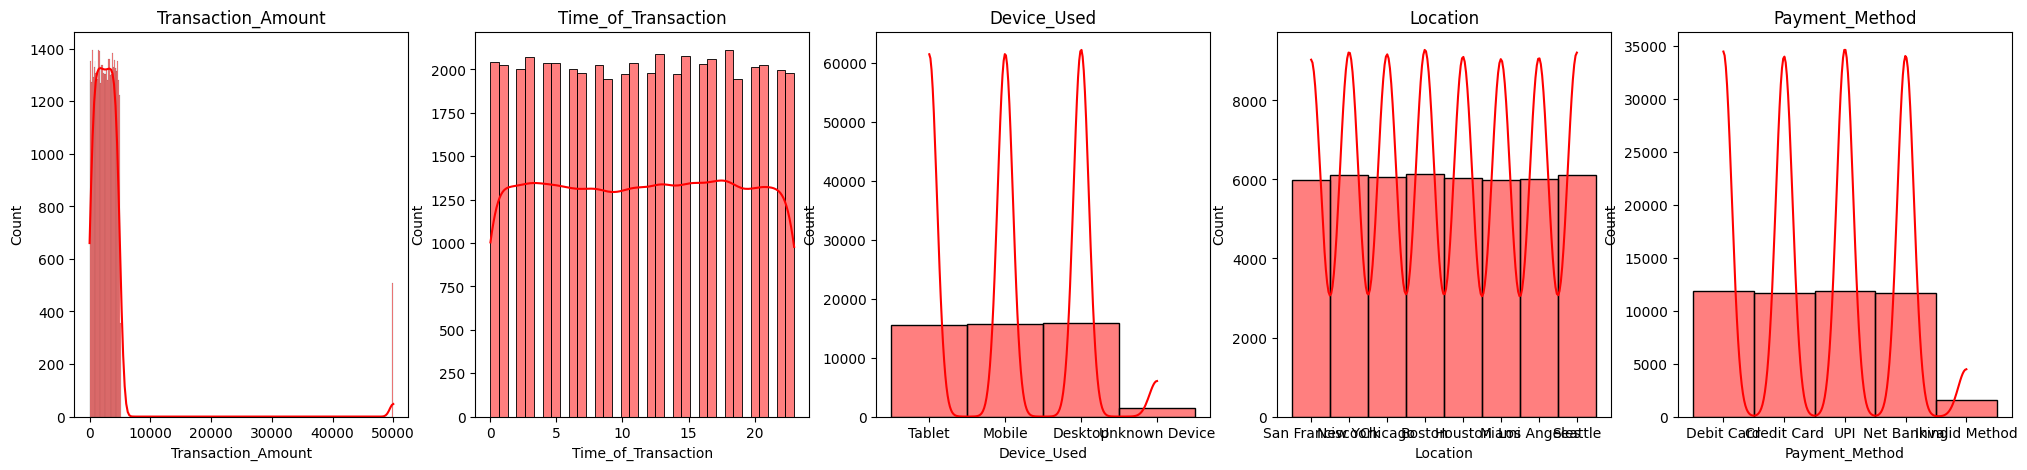

<Figure size 1000x1000 with 0 Axes>

In [35]:
missing_cols = [col for col in df.columns if df[col].isnull().sum() > 0]

fig, axes = plt.subplots(1, len(missing_cols), figsize=(5 * len(missing_cols), 5))

if len(missing_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, missing_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='red')
    ax.set_title(col)

plt.figure(figsize=(10, 10))
plt.tight_layout()
plt.show()

#### Handling missing values with some random constant string is best in this situation, because only columns which contain numerical features are Transaction_Amount and Time_of_Transaction. So we will handle the categorical featured columns by replacing Nan with constant string, and numerical by replacing mean

In [36]:
for col in df.columns:
    if df[col].dtype == 'object':  
        df[col] = df[col].fillna('Unknown')  
    else:  
        df[col] = df[col].fillna(df[col].mean())  

In [37]:
df.isnull().sum()

Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64

Now lets review Transaction_ID and User_ID, because their importance in the modelling is questionable

In [38]:
print("Unique Data of Transaction_ID:", len(df['Transaction_ID'].unique()))
print("Unique Data Of User_ID:", len(df['User_ID'].unique()))

Unique Data of Transaction_ID: 50000
Unique Data Of User_ID: 4000


All of the values in the transaction column is not important for the prediction, so we can drop them out of the dataset. But the User_ID column holds important information, because one account is used per fraud, so our model will notice it

In [39]:
df.drop(['Transaction_ID'], axis=1, inplace=True)

Now its time for the statistical review. Since we still have the 'object' type features, we must try encoding. For EDA, the best encoding is LabelEncoder, because we can fully review the options. Other type of encodings will create too much columns, which will mess up the statistics. For modelling, we can use OneHotEncoding.

## 2nd Method using Ydata_profiling library 

In [40]:
!pip install ydata-profiling -q

In [41]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df,title="Fraud Analysis Report", explorative=True)
profile.to_file("analysis_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:00<00:00, 42.90it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### this library gives us a HTML file that contains all different amont of EDA about our data in which is a great way to explore the data we have in a faster way then the traditionnal way 

# Data Preprocessing 


In [42]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_eda = df.copy()
df_train = df.copy()

categorical_features = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']

for col in categorical_features:
    df_eda[col] = le.fit_transform(df_eda[col])

df_train = pd.get_dummies(df_train, columns=categorical_features)

In [43]:
print('Train Dataset:')
df_train.head()

Train Dataset:


,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent,Transaction_Type_ATM Withdrawal,Transaction_Type_Bank Transfer,Transaction_Type_Bill Payment,...,Location_New York,Location_San Francisco,Location_Seattle,Location_Unknown,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_Invalid Method,Payment_Method_Net Banking,Payment_Method_UPI,Payment_Method_Unknown
0,4174,1292.76,16.0000,0,119,13,0,True,False,False,...,False,True,False,False,False,True,False,False,False,False
1,4507,1554.58,13.0000,4,79,3,0,True,False,False,...,True,False,False,False,True,False,False,False,False,False
2,1860,2395.02,11.4884,3,115,9,0,True,False,False,...,False,False,False,True,False,False,False,False,False,True
3,2294,100.10,15.0000,4,3,4,0,False,False,True,...,False,False,False,False,False,False,False,False,True,False
4,2130,1490.50,19.0000,2,57,7,0,False,False,False,...,False,True,False,False,True,False,False,False,False,False


In [44]:
print('EDA Dataset:')
df_eda.head()

EDA Dataset:


,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,4174,1292.76,0,16.0000,2,6,0,119,13,1,0
1,4507,1554.58,0,13.0000,1,5,4,79,3,0,0
2,1860,2395.02,0,11.4884,1,8,3,115,9,5,0
3,2294,100.10,2,15.0000,0,1,4,3,4,4,0
4,2130,1490.50,4,19.0000,1,6,2,57,7,0,0
